In [24]:
# Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [119]:
# Pulling in the master dataset
df = pd.read_csv('data/master_zillow_with_taxes.csv')
df.columns

Index(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',
       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',
       'zestimate', 'detail_url', 'has_open_house', 'is_featured',
       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',
       'state_name', 'state_avg_housing_value', 'state_avg_prop_tax_rate',
       'med_prop_tax_paid', 'single_filer_rates', 'single_filer_brackets',
       'married_filing_jointly_rates', 'married_filing_jointly_brackets'],
      dtype='str')

In [120]:
# Filtering the dataframe to only have houses that can  be purchased
print('======Before======')
print(df['status'].value_counts())

drop_vals = ['Coming Soon', 'Coming soon','Foreclosure', 'Auction', 'New']
df_filtered = df[~df['status'].isin(drop_vals)]
print('======After======')
print(df_filtered['status'].value_counts())
# Checking how many null values 
df_filtered.isnull().sum()
# Using the median for null values in area_sqft
df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(
    df_filtered["area_sqft"].median()
)
# Only had 1 null in longitude and latitude so decided to drop it
df_filtered = df_filtered.dropna(subset=["latitude", "longitude"])
df_filtered.isnull().sum()


======Before======
status
House for sale           1494
Active                    353
Coming soon               223
Condo for sale             19
Townhouse for sale         14
Active Under Contract      14
New construction           13
Foreclosure                11
For sale by owner           8
Auction                     6
Coming Soon                 3
New                         1
Name: count, dtype: int64
======After======
status
House for sale           1494
Active                    353
Condo for sale             19
Townhouse for sale         14
Active Under Contract      14
New construction           13
For sale by owner           8
Name: count, dtype: int64


Unnamed: 0                           0
zpid                                 0
address                              0
price                                0
beds                                 0
baths                                0
area_sqft                            0
latitude                             0
longitude                            0
status                               0
home_type                            0
days_on_zillow                       0
zestimate                          926
detail_url                           0
has_open_house                       0
is_featured                          0
street_add                           0
city                                 0
state_zipcode                        0
state_code                           0
zipcode                              0
state_name                           0
state_avg_housing_value              0
state_avg_prop_tax_rate              0
med_prop_tax_paid                    0
single_filer_rates       

In [121]:
#Trying to get rid of extreme outliers on both the low and high ends of prices
df_filtered = df_filtered[df_filtered['price'] > 10000]

cap = df_filtered['price'].quantile(0.99)
print(f"Capping at: ${cap:,.0f}")
df_filtered = df_filtered[df_filtered['price'] <= cap]

print(f"Rows remaining: {len(df_filtered)}")
print(df_filtered['price'].describe())

Capping at: $22,983,600
Rows remaining: 1893
count    1.893000e+03
mean     7.900074e+05
std      1.571539e+06
min      1.790000e+04
25%      3.390000e+05
50%      4.990000e+05
75%      7.620000e+05
max      2.290000e+07
Name: price, dtype: float64


In [122]:
# Dropping columns that are redundant or unhelpful
# Not sure if I should include zestimate, is_featured, and has_opened_house
# Also not sure about zipcode, city, and state name because they are string and if you one hot encode it would be a lot of columns
features = ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'home_type', 
            'days_on_zillow', 'state_avg_housing_value', 'state_avg_prop_tax_rate', 
            'med_prop_tax_paid']
target = 'price'

X = df_filtered[features]
# Adding dummy variables for one-hot encoding
X = pd.get_dummies(X, columns=["home_type"], drop_first=True)
# Changing the target outcome to be between 0 and 1
y = np.log(df_filtered[target])

# Splitting the data with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [123]:
# Just checking if the train and test data will look similar as I have been cleaning and dropping alot
train_df = X_train.copy()
test_df = X_test.copy()

train_df["price"] = y_train
test_df["price"] = y_test

print("TRAIN SUMMARY")
print(train_df.describe())

print("\nTEST SUMMARY")
print(test_df.describe())

TRAIN SUMMARY
              beds        baths     area_sqft     latitude    longitude  \
count  1514.000000  1514.000000   1514.000000  1514.000000  1514.000000   
mean      3.652576     2.831572   2539.266182    39.336758   -93.330114   
std       1.099557     1.248410   1772.320456     4.681565    16.623753   
min       0.000000     0.000000      0.000000    27.480639  -124.097000   
25%       3.000000     2.000000   1666.250000    35.918706  -108.525145   
50%       4.000000     3.000000   2214.000000    39.606266   -90.604162   
75%       4.000000     3.000000   2846.250000    42.769367   -78.558770   
max      17.000000    12.000000  29087.000000    48.790657   -69.429490   

       days_on_zillow  state_avg_housing_value  state_avg_prop_tax_rate  \
count     1514.000000              1514.000000              1514.000000   
mean        24.057464            293956.705485                 0.909336   
std         61.957867            127860.474811                 0.491118   
min       

In [124]:
# Scaling the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

alphas = np.logspace(-3, 6, 200)
alphas

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train)

print("Best alpha (Ridge):", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_sc, y_train)

print("Best alpha (Lasso):", lasso.alpha_)


for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test = model.predict(X_test_sc)
    y_pred_train = model.predict(X_train_sc)
    mse_test  = mean_squared_error(y_test, y_pred_test)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_test = np.sqrt(mse_test)
    rmse_train = np.sqrt(mse_train)
    r2_test   = r2_score(y_test, y_pred_test)
    r2_train   = r2_score(y_train, y_pred_train)
    print(f"\n{name}")
    print(f"  Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)

Best alpha (Ridge): 217.11179456945052
Best alpha (Lasso): 0.01663816886076129

Lasso
  Train MSE: 0.2472 | Test MSE: 0.2223
  Train RMSE: 0.4972 | Test RMSE: 0.4715
  Train R2:  0.5577 | Test R2:  0.6061

Ridge
  Train MSE: 0.2480 | Test MSE: 0.2234
  Train RMSE: 0.4980 | Test RMSE: 0.4726
  Train R2:  0.5563 | Test R2:  0.6042


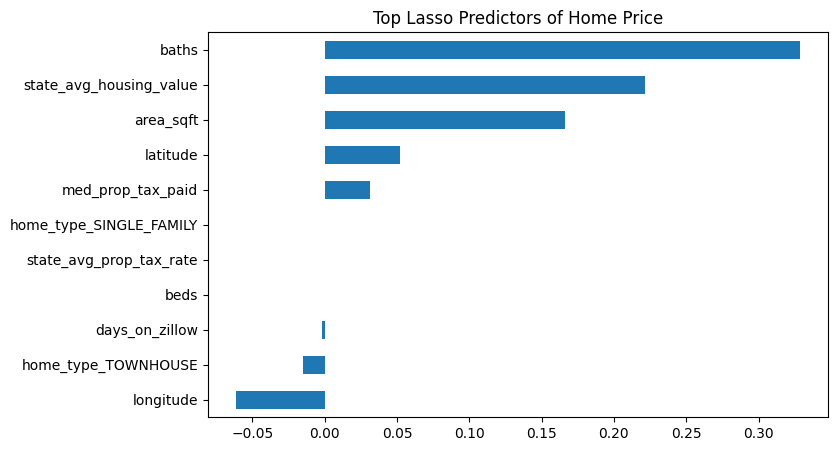

In [125]:
# Visualizations for Lasso coefficients 
top = lasso_sorted

plt.figure(figsize=(8,5))
top.sort_values().plot(kind="barh")
plt.title("Top Lasso Predictors of Home Price")
plt.show()

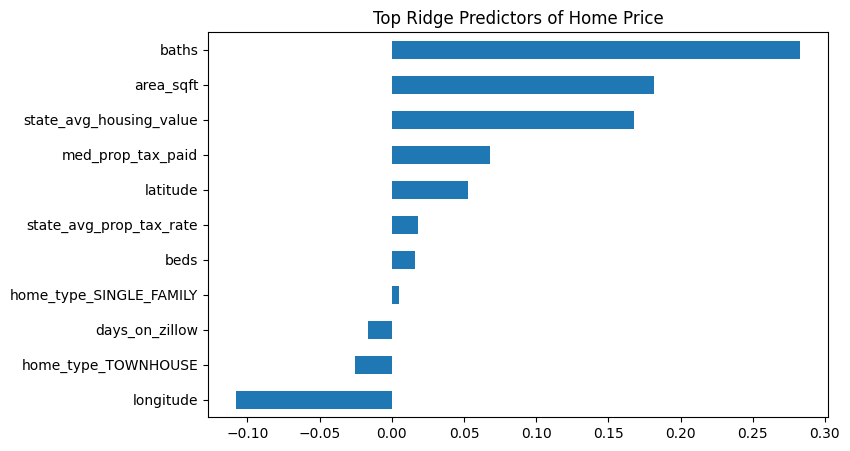

In [ ]:
# Visualizations for Ridge (probably not super necessary but just good to compare to )
top_ridge = ridge_sorted

plt.figure(figsize=(8,5))
top_ridge.sort_values().plot(kind="barh")
plt.title("Top Ridge Predictors of Home Price")
plt.show()